In [2]:
import torch
from torch_geometric.datasets import TUDataset
from rdkit import Chem
from rdkit.Chem import Draw

# 1. Load the PyG MUTAG dataset
print("Loading MUTAG dataset...")
dataset = TUDataset(root='./data', name='MUTAG')

# 2. Define mappings based on PyG's MUTAG encoding
# MUTAG Node features (one-hot): 0:C, 1:N, 2:O, 3:F, 4:I, 5:Cl, 6:Br
atom_map = {0: 6, 1: 7, 2: 8, 3: 9, 4: 53, 5: 17, 6: 35} # RDKit Atomic numbers

# MUTAG Edge features (one-hot): 0:Aromatic, 1:Single, 2:Double, 3:Triple
bond_map = {
    0: Chem.BondType.AROMATIC,
    1: Chem.BondType.SINGLE,
    2: Chem.BondType.DOUBLE,
    3: Chem.BondType.TRIPLE
}

def pyg_data_to_rdkit_mol(data):
    """Converts PyG Data object back to an RDKit molecule."""
    mol = Chem.RWMol()
    
    # Add Atoms
    node_labels = data.x.argmax(dim=1)
    for label in node_labels:
        atom_idx = atom_map[label.item()]
        mol.AddAtom(Chem.Atom(atom_idx))
        
    # Add Bonds
    edge_index = data.edge_index
    edge_attr = data.edge_attr.argmax(dim=1)
    
    added_bonds = set()
    for i in range(edge_index.size(1)):
        u, v = edge_index[0, i].item(), edge_index[1, i].item()
        # PyG graphs are undirected (edges exist both ways). Only add bond once.
        if u < v: 
            bond_type = bond_map[edge_attr[i].item()]
            mol.AddBond(u, v, bond_type)
            
    mol = mol.GetMol()
    
    # Generate 2D coordinates for visualization
    # Note: We wrap sanitization in a try/except because TUDataset graphs 
    # sometimes lack explicit hydrogens, which can fail RDKit's strict valency checks.
    try:
        Chem.SanitizeMol(mol)
    except:
        pass 
        
    Chem.rdDepictor.Compute2DCoords(mol)
    return mol

# 3. Collect 10 samples from each class
mutagenic_mols = []
non_mutagenic_mols = []

for data in dataset:
    if data.y.item() == 1 and len(mutagenic_mols) < 10:
        mutagenic_mols.append(pyg_data_to_rdkit_mol(data))
    elif data.y.item() == 0 and len(non_mutagenic_mols) < 10:
        non_mutagenic_mols.append(pyg_data_to_rdkit_mol(data))
        
    if len(mutagenic_mols) == 10 and len(non_mutagenic_mols) == 10:
        break

# 4. Visualize and save the grids
print("Generating images...")

# Draw Mutagenic (Class 1)
img_mutagenic = Draw.MolsToGridImage(
    mutagenic_mols, 
    molsPerRow=5, 
    subImgSize=(300, 300), 
    legends=[f"Mutagenic {i+1}" for i in range(10)]
)
img_mutagenic

# Draw Non-Mutagenic (Class 0)
img_non_mutagenic = Draw.MolsToGridImage(
    non_mutagenic_mols, 
    molsPerRow=5, 
    subImgSize=(300, 300), 
    legends=[f"Non-Mutagenic {i+1}" for i in range(10)]
)
img_non_mutagenic

print("Done! Check your directory for 'mutagenic_samples.png' and 'non_mutagenic_samples.png'.")

Loading MUTAG dataset...
Generating images...
Done! Check your directory for 'mutagenic_samples.png' and 'non_mutagenic_samples.png'.


[16:47:01] Explicit valence for atom # 14 N, 4, is greater than permitted
[16:47:01] Explicit valence for atom # 10 N, 4, is greater than permitted
[16:47:01] Explicit valence for atom # 10 N, 4, is greater than permitted
[16:47:01] Explicit valence for atom # 16 N, 4, is greater than permitted
[16:47:01] Explicit valence for atom # 7 N, 4, is greater than permitted
[16:47:01] Explicit valence for atom # 16 N, 4, is greater than permitted
[16:47:01] Explicit valence for atom # 7 N, 4, is greater than permitted
[16:47:01] Explicit valence for atom # 17 N, 4, is greater than permitted
[16:47:01] Explicit valence for atom # 9 N, 4, is greater than permitted
[16:47:01] Explicit valence for atom # 14 N, 4, is greater than permitted
[16:47:01] Explicit valence for atom # 14 N, 4, is greater than permitted
[16:47:01] Explicit valence for atom # 17 N, 4, is greater than permitted
[16:47:01] Explicit valence for atom # 16 N, 4, is greater than permitted
[16:47:01] Explicit valence for atom # 1 

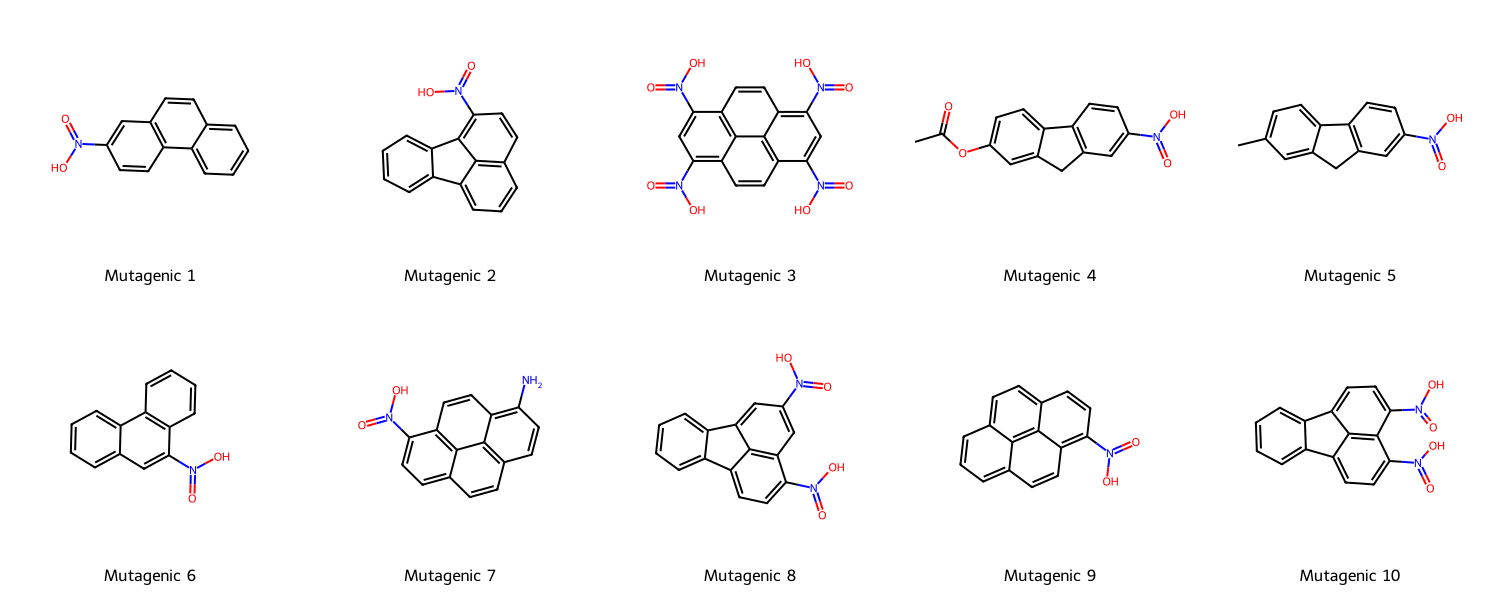

In [3]:
img_mutagenic

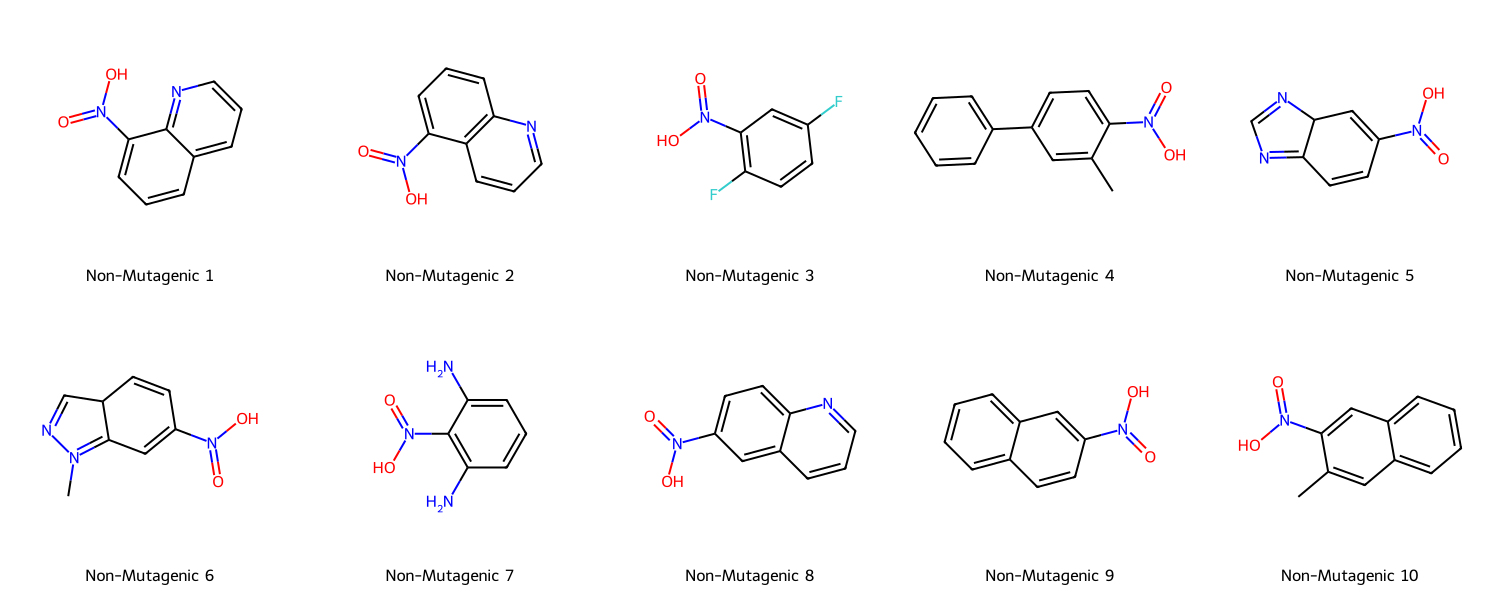

In [5]:
img_non_mutagenic